<a href="https://colab.research.google.com/github/luisy-eng/ECE491_Lab2/blob/main/Task3/fgsm_defenses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Implementation
==============

In this section, we will discuss the input parameters for the tutorial,
define the model under attack, then code the attack and run some tests.

Inputs
------

There are only three inputs for this tutorial, and are defined as
follows:

-   `epsilons` - List of epsilon values to use for the run. It is
    important to keep 0 in the list because it represents the model
    performance on the original test set. Also, intuitively we would
    expect the larger the epsilon, the more noticeable the perturbations
    but the more effective the attack in terms of degrading model
    accuracy. Since the data range here is $[0,1]$, no epsilon value
    should exceed 1.
-   `pretrained_model` - path to the pretrained MNIST model which was
    trained with
    [pytorch/examples/mnist](https://github.com/pytorch/examples/tree/master/mnist).
    For simplicity, download the pretrained model
    [here](https://drive.google.com/file/d/1HJV2nUHJqclXQ8flKvcWmjZ-OU5DGatl/view?usp=drive_link).


In [3]:
epsilons = [0, .05, .1, .15, .2, .25, .3]
pretrained_model = "data/lenet_mnist_model.pth"
# Set random seed for reproducibility
torch.manual_seed(42)

Model Under Attack
==================

As mentioned, the model under attack is the same MNIST model from
[pytorch/examples/mnist](https://github.com/pytorch/examples/tree/master/mnist).
You may train and save your own MNIST model or you can download and use
the provided model. The *Net* definition and test dataloader here have
been copied from the MNIST example. The purpose of this section is to
define the model and dataloader, then initialize the model and load the
pretrained weights.


In [8]:
# LeNet Model definition
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        self.conv2_drop = nn.Dropout2d()

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):

        x = F.relu(F.max_pool2d(self.conv1(x), 2))

        x = F.relu(
            F.max_pool2d(
                self.conv2_drop(self.conv2(x)),
                2
            )
        )

        x = x.view(-1, 320)

        x = F.relu(self.fc1(x))

        x = F.dropout(x, training=self.training)

        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

# MNIST Test dataset and dataloader declaration
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            ])),
        batch_size=1, shuffle=True)

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Initialize the network
model = Net().to(device)

# Create directory for pretrained model
!mkdir -p data

# Download the official pretrained MNIST model
!wget -q --show-progress \
https://s3.amazonaws.com/pytorch-tutorial-assets/lenet_mnist_model.pth \
-O data/lenet_mnist_model.pth

# Load the pretrained model
model.load_state_dict(torch.load(pretrained_model, map_location=device, weights_only=True))

# Set the model in evaluation mode. In this case this is for the Dropout layers
model.eval()

Using cuda device
data/lenet_mnist_mo 100%[===================>]  86.64K  --.-KB/s    in 0.1s    


Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

Attack
===========



In [33]:
# ==========================================================
# Task 3 - Attack and Defense Functions
# ==========================================================


# ----------------------------------------------------------
# Targeted FGSM Attack from Task 2
# ----------------------------------------------------------

def targeted_fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    # Targeted FGSM subtracts the gradient
    perturbed_image = image - epsilon * sign_data_grad

    # Keep pixels in valid MNIST range
    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    return perturbed_image


# ----------------------------------------------------------
# Restore normalized MNIST image to [0,1]
# ----------------------------------------------------------

def denorm(batch, mean=[0.1307], std=[0.3081]):

    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)

    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return (
        batch * std.view(1, -1, 1, 1)
        + mean.view(1, -1, 1, 1)
    )


# ==========================================================
# DENOISING DEFENSES
# ==========================================================


# ----------------------------------------------------------
# Defense 1: Gaussian Blur
# ----------------------------------------------------------

def gaussian_blur_defense(
    image,
    kernel_size=3,
    sigma=1.0
):

    defended = TF.gaussian_blur(
        image,
        kernel_size=[kernel_size, kernel_size],
        sigma=[sigma, sigma]
    )

    return torch.clamp(
        defended,
        0,
        1
    )


# ----------------------------------------------------------
# Defense 2: Mean / Box Filter
# ----------------------------------------------------------

def mean_filter_defense(
    image,
    kernel_size=3
):

    padding = kernel_size // 2

    defended = F.avg_pool2d(
        image,
        kernel_size=kernel_size,
        stride=1,
        padding=padding
    )

    return torch.clamp(
        defended,
        0,
        1
    )


# ----------------------------------------------------------
# Defense 3: Median Filter
# ----------------------------------------------------------

def median_filter_defense(
    image,
    kernel_size=3
):

    padding = kernel_size // 2

    padded = F.pad(
        image,
        (padding, padding, padding, padding),
        mode="reflect"
    )

    patches = padded.unfold(
        2,
        kernel_size,
        1
    ).unfold(
        3,
        kernel_size,
        1
    )

    patches = patches.contiguous().view(
        *patches.shape[:4],
        -1
    )

    defended = patches.median(
        dim=-1
    ).values

    return torch.clamp(
        defended,
        0,
        1
    )


# ==========================================================
# NOISE DEFENSE
# ==========================================================

def gaussian_noise_defense(
    image,
    noise_std
):

    noise = (
        torch.randn_like(image)
        * noise_std
    )

    defended = image + noise

    return torch.clamp(
        defended,
        0,
        1
    )

Testing Function
================




In [34]:
# ==========================================================
# Task 3 - Defense Evaluation
# ==========================================================

def evaluate_defense(
    model,
    device,
    test_loader,
    epsilon,
    defense_function=None,
    defense_kwargs=None,
    target_label=5
):

    # Disable dropout during evaluation
    model.eval()

    if defense_kwargs is None:
        defense_kwargs = {}

    total_attempts = 0
    successful_attacks = 0

    # MNIST normalization used by the pretrained model
    normalize = transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )

    # ------------------------------------------------------
    # Loop through MNIST test images
    # ------------------------------------------------------

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        true_label = target.item()

        # Do not attack images that are already class 5
        if true_label == target_label:
            continue

        # Gradient is needed with respect to the input image
        data.requires_grad = True

        # --------------------------------------------------
        # 1. Initial prediction
        # --------------------------------------------------

        output = model(data)

        initial_pred = output.argmax(dim=1)

        # Only attack correctly classified samples
        if initial_pred.item() != true_label:
            continue

        total_attempts += 1

        # --------------------------------------------------
        # 2. Target class = 5
        # --------------------------------------------------

        target_tensor = torch.full_like(
            target,
            target_label
        )

        loss = F.nll_loss(
            output,
            target_tensor
        )

        model.zero_grad()

        loss.backward()

        data_grad = data.grad.data

        # --------------------------------------------------
        # 3. Convert image back to [0,1]
        # --------------------------------------------------

        data_denorm = denorm(data)

        # --------------------------------------------------
        # 4. Generate targeted FGSM adversarial image
        # --------------------------------------------------

        adversarial_image = targeted_fgsm_attack(
            data_denorm,
            epsilon,
            data_grad
        )

        # --------------------------------------------------
        # 5. Apply defense
        # --------------------------------------------------

        if defense_function is not None:

            defended_image = defense_function(
                adversarial_image,
                **defense_kwargs
            )

        else:

            # No defense = baseline
            defended_image = adversarial_image

        # --------------------------------------------------
        # 6. Normalize image for neural network
        # --------------------------------------------------

        defended_normalized = normalize(
            defended_image
        )

        # --------------------------------------------------
        # 7. Final prediction
        # --------------------------------------------------

        with torch.no_grad():

            output = model(
                defended_normalized
            )

            final_pred = output.argmax(
                dim=1
            ).item()

        # Attack remains successful if prediction is still 5
        if final_pred == target_label:

            successful_attacks += 1

    # ------------------------------------------------------
    # Attack Success Rate
    # ------------------------------------------------------

    attack_success_rate = (
        successful_attacks / total_attempts
        if total_attempts > 0
        else 0
    )

    return (
        attack_success_rate,
        successful_attacks,
        total_attempts
    )

In [35]:
baseline_asr, successful, total = evaluate_defense(
    model,
    device,
    test_loader,
    epsilon=0.30,
    defense_function=None,
    target_label=5
)

print(f"Successful attacks: {successful}/{total}")
print(
    f"Baseline targeted attack success rate: "
    f"{baseline_asr * 100:.2f}%"
)

Successful attacks: 3510/8965
Baseline targeted attack success rate: 39.15%


Run Attack
==========



In [36]:
# ==========================================================
# Task 3 - Denoising Defense Experiments
# ==========================================================

epsilon = 0.30

# Gaussian Blur
gaussian_asr, gaussian_successful, gaussian_total = evaluate_defense(
    model,
    device,
    test_loader,
    epsilon=epsilon,
    defense_function=gaussian_blur_defense,
    defense_kwargs={
        "kernel_size": 3,
        "sigma": 1.0
    },
    target_label=5
)

# Mean Filter
mean_asr, mean_successful, mean_total = evaluate_defense(
    model,
    device,
    test_loader,
    epsilon=epsilon,
    defense_function=mean_filter_defense,
    defense_kwargs={
        "kernel_size": 3
    },
    target_label=5
)

# Median Filter
median_asr, median_successful, median_total = evaluate_defense(
    model,
    device,
    test_loader,
    epsilon=epsilon,
    defense_function=median_filter_defense,
    defense_kwargs={
        "kernel_size": 3
    },
    target_label=5
)

print("Targeted FGSM Defense Results")
print("--------------------------------------")

print(
    f"No Defense:     {baseline_asr * 100:.2f}% "
    f"({successful}/{total})"
)

print(
    f"Gaussian Blur:  {gaussian_asr * 100:.2f}% "
    f"({gaussian_successful}/{gaussian_total})"
)

print(
    f"Mean Filter:    {mean_asr * 100:.2f}% "
    f"({mean_successful}/{mean_total})"
)

print(
    f"Median Filter:  {median_asr * 100:.2f}% "
    f"({median_successful}/{median_total})"
)

Targeted FGSM Defense Results
--------------------------------------
No Defense:     39.15% (3510/8965)
Gaussian Blur:  26.99% (2420/8965)
Mean Filter:    24.09% (2160/8965)
Median Filter:  25.02% (2243/8965)


Results
=======







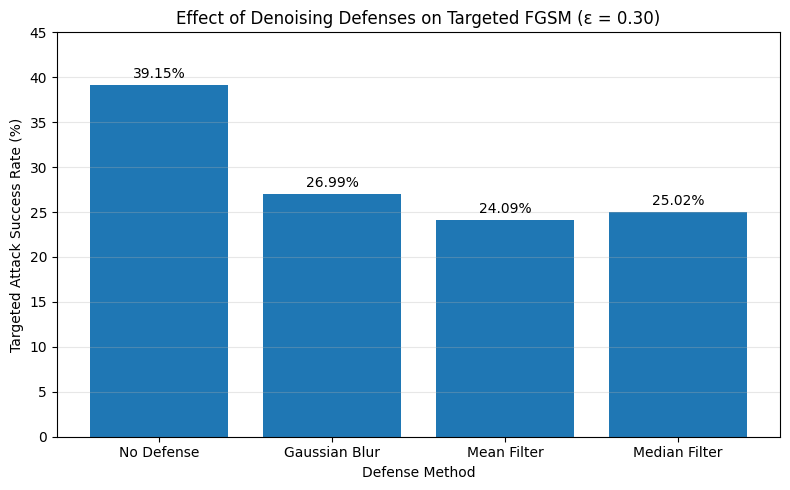

In [37]:
# ==========================================================
# Plot Denoising Defense Results
# ==========================================================

defense_names = [
    "No Defense",
    "Gaussian Blur",
    "Mean Filter",
    "Median Filter"
]

attack_success_rates = [
    baseline_asr * 100,
    gaussian_asr * 100,
    mean_asr * 100,
    median_asr * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    defense_names,
    attack_success_rates
)

plt.ylabel("Targeted Attack Success Rate (%)")
plt.xlabel("Defense Method")
plt.title(
    "Effect of Denoising Defenses on Targeted FGSM "
    "(ε = 0.30)"
)

plt.ylim(0, 45)

# Add values above bars
for bar, value in zip(bars, attack_success_rates):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "task3_denoising_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Denoising Defense Results

All three denoising techniques reduced the effectiveness of the
targeted FGSM attack at ε = 0.30.

The undefended targeted attack achieved a success rate of 39.15%.
Gaussian blur reduced the attack success rate to 26.99%, while the
median filter reduced it to 25.02%. The mean filter produced the
lowest attack success rate at 24.09%, making it the most effective
denoising defense tested in this experiment.

Noise Defense Experiment
===========================



In [38]:
# ==========================================================
# Task 3 - Gaussian Noise Defense Experiments
# ==========================================================

noise_levels = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20
]

noise_results = []

for noise_std in noise_levels:

    asr, successful_attacks, total_attacks = evaluate_defense(
        model,
        device,
        test_loader,
        epsilon=0.30,
        defense_function=gaussian_noise_defense,
        defense_kwargs={
            "noise_std": noise_std
        },
        target_label=5
    )

    noise_results.append(asr)

    print(
        f"Noise std = {noise_std:.2f} | "
        f"ASR = {asr * 100:.2f}% "
        f"({successful_attacks}/{total_attacks})"
    )

Noise std = 0.00 | ASR = 39.15% (3510/8965)
Noise std = 0.02 | ASR = 38.74% (3473/8965)
Noise std = 0.05 | ASR = 38.00% (3407/8965)
Noise std = 0.10 | ASR = 36.12% (3238/8965)
Noise std = 0.15 | ASR = 34.01% (3049/8965)
Noise std = 0.20 | ASR = 31.91% (2861/8965)


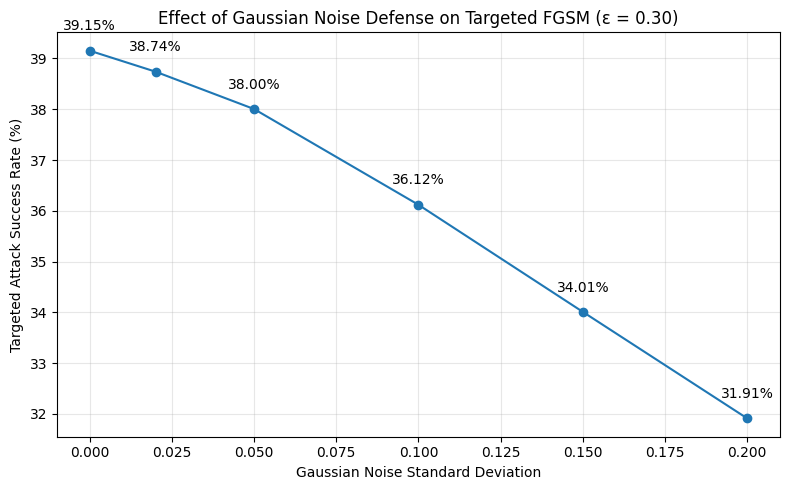

In [39]:
# ==========================================================
# Plot Gaussian Noise Defense Results
# ==========================================================

noise_percentages = [
    result * 100
    for result in noise_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    noise_levels,
    noise_percentages,
    marker="o"
)

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Targeted Attack Success Rate (%)")

plt.title(
    "Effect of Gaussian Noise Defense on Targeted FGSM "
    "(ε = 0.30)"
)

plt.grid(True, alpha=0.3)

# Label each point
for x, y in zip(noise_levels, noise_percentages):
    plt.text(
        x,
        y + 0.4,
        f"{y:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "task3_noise_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Gaussian Noise Defense Results

Increasing the amount of Gaussian noise reduced the effectiveness of
the targeted FGSM attack. With no additional noise, the targeted attack
success rate was 39.15%. A small noise standard deviation of 0.02 only
reduced the success rate slightly to 38.74%.

As the noise level increased, the attack success rate continued to
decrease. At a standard deviation of 0.10, the attack success rate was
36.12%, while a standard deviation of 0.20 reduced it to 31.91%.

Although Gaussian noise reduced the targeted attack success rate, the
denoising filters were more effective. The best denoising result was
obtained using the mean filter, which reduced the attack success rate
to 24.09%.

In [44]:
# ==========================================================
# Generate Task 3 Visual Example
# ==========================================================

def get_defense_example(
    model,
    device,
    test_loader,
    epsilon=0.30,
    target_label=5
):

    model.eval()

    normalize = transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        true_label = target.item()

        if true_label == target_label:
            continue

        data.requires_grad = True

        # -----------------------------------
        # Original prediction
        # -----------------------------------

        output = model(data)
        initial_pred = output.argmax(dim=1).item()

        if initial_pred != true_label:
            continue

        # -----------------------------------
        # Targeted FGSM attack
        # -----------------------------------

        target_tensor = torch.full_like(
            target,
            target_label
        )

        loss = F.nll_loss(
            output,
            target_tensor
        )

        model.zero_grad()
        loss.backward()

        data_grad = data.grad.data

        original_image = denorm(data)

        adversarial_image = targeted_fgsm_attack(
            original_image,
            epsilon,
            data_grad
        )

        # Adversarial prediction
        with torch.no_grad():

            adv_pred = model(
                normalize(adversarial_image)
            ).argmax(dim=1).item()

        # Only keep successful attacks
        if adv_pred != target_label:
            continue

        # -----------------------------------
        # Apply defenses
        # -----------------------------------

        gaussian_image = gaussian_blur_defense(
            adversarial_image,
            kernel_size=3,
            sigma=1.0
        )

        mean_image = mean_filter_defense(
            adversarial_image,
            kernel_size=3
        )

        median_image = median_filter_defense(
            adversarial_image,
            kernel_size=3
        )

        noise_image = gaussian_noise_defense(
            adversarial_image,
            noise_std=0.20
        )

        # -----------------------------------
        # Predictions after defenses
        # -----------------------------------

        with torch.no_grad():

            gaussian_pred = model(
                normalize(gaussian_image)
            ).argmax(dim=1).item()

            mean_pred = model(
                normalize(mean_image)
            ).argmax(dim=1).item()

            median_pred = model(
                normalize(median_image)
            ).argmax(dim=1).item()

            noise_pred = model(
                normalize(noise_image)
            ).argmax(dim=1).item()

        # -----------------------------------
        # Choose an example where at least
        # one defense defeats target class 5
        # -----------------------------------

        defense_predictions = [
            gaussian_pred,
            mean_pred,
            median_pred,
            noise_pred
        ]

        if any(
            pred != target_label
            for pred in defense_predictions
        ):

            return {
                "true_label": true_label,
                "original": original_image,
                "adversarial": adversarial_image,
                "gaussian": gaussian_image,
                "mean": mean_image,
                "median": median_image,
                "noise": noise_image
            }

In [45]:
example = get_defense_example(
    model,
    device,
    test_loader,
    epsilon=0.30,
    target_label=5
)

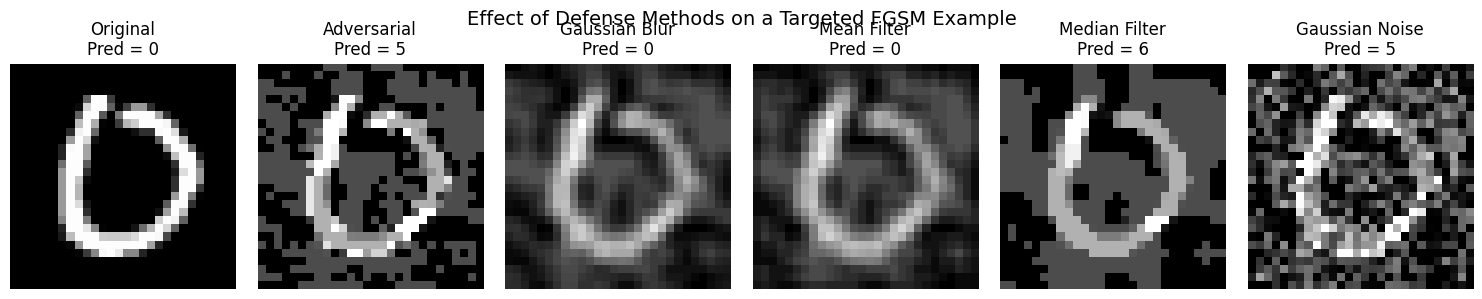

In [46]:
# ==========================================================
# Plot Defense Image Comparison with Predictions
# ==========================================================

normalize = transforms.Normalize(
    (0.1307,),
    (0.3081,)
)

def predict_image(image):
    """
    Predict the class of an image stored in [0,1] pixel range.
    """

    image_normalized = normalize(image)

    with torch.no_grad():
        output = model(image_normalized)

    return output.argmax(dim=1).item()


# Get prediction for every image
original_pred = predict_image(example["original"])
adversarial_pred = predict_image(example["adversarial"])
gaussian_pred = predict_image(example["gaussian"])
mean_pred = predict_image(example["mean"])
median_pred = predict_image(example["median"])
noise_pred = predict_image(example["noise"])


images = [
    example["original"],
    example["adversarial"],
    example["gaussian"],
    example["mean"],
    example["median"],
    example["noise"]
]

titles = [
    f"Original\nPred = {original_pred}",
    f"Adversarial\nPred = {adversarial_pred}",
    f"Gaussian Blur\nPred = {gaussian_pred}",
    f"Mean Filter\nPred = {mean_pred}",
    f"Median Filter\nPred = {median_pred}",
    f"Gaussian Noise\nPred = {noise_pred}"
]


fig, axes = plt.subplots(
    1,
    6,
    figsize=(15, 3)
)

for ax, image, title in zip(
    axes,
    images,
    titles
):

    ax.imshow(
        image.squeeze().detach().cpu().numpy(),
        cmap="gray"
    )

    ax.set_title(title)
    ax.axis("off")


plt.suptitle(
    "Effect of Defense Methods on a Targeted FGSM Example",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "task3_defense_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()